In [6]:
# Import packages
import random
import numpy as np
from numpy.typing import NDArray
from typing import List, Dict
import time
import math
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
import tensorflow as tf
from tensorflow import Tensor

# List available physical devices
physical_devices = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(physical_devices))

# If GPUs are found, check if TensorFlow is built with CUDA/ROCm support
if len(physical_devices) > 0:
    print("TensorFlow is built with GPU support:", tf.test.is_built_with_cuda())

2025-08-23 16:20:55.858333: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-23 16:20:56.333888: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-23 16:20:57.683709: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Num GPUs Available:  1
TensorFlow is built with GPU support: True


In [8]:
# Generate random positive/negative lists representing the dataset and model predictions
DATA_SIZE = 10000000
DATA_PERCENT_POSITIVE = 0.01
MODEL_PERCENT_POSITIVE = 0.2

data_set = [1 if random.random() < DATA_PERCENT_POSITIVE else 0 for x in range(DATA_SIZE)]

# Assuming uniform distribution from random.random(), using the below equation should result in a distribution that
# should maintain the desired positive/negative split for model predictions at a threshold of 0.5
confidence_exponent = math.log(0.5)/math.log(1 - MODEL_PERCENT_POSITIVE)
model_confidences = [random.random()**confidence_exponent for x in range(DATA_SIZE)]
model_predictions = [1 if model_confidences[x] > 0.5 else 0 for x in range(DATA_SIZE)]

Based on the probabilities provided above, we should expect the following distribution for the confusion matrix:
|   | Predicted Negative | Predicted Positive |
| - | ------------------ | ------------------ |
| Actual Negative | 79.2% (7,920,000) | 19.8% (1,980,000) |
| Actual Positive | 0.8% (80,000) | 0.2% (20,000) |

In [9]:
# An implementation of computing the confusion matrix in serial
def produce_confusion_matrix_serial(actual : List | NDArray, predicted : List | NDArray) -> NDArray:
    assert len(actual) == len(predicted)
    confusion_matrix = np.array([[0, 0], [0, 0]])
    for i in range(len(actual)):
        if actual[i] == predicted[i]:
            if actual[i] == 0:
                # True Negative
                confusion_matrix[0][0] += 1
            else:
                # True Positive
                confusion_matrix[1][1] += 1
        else:
            if actual[i] == 0:
                # False Positive
                confusion_matrix[0][1] += 1
            else:
                # False Negative
                confusion_matrix[1][0] += 1
    return confusion_matrix

In [23]:
# An implementation of computing the confusion matrix in parallel, using arithmetic
def produce_confusion_matrix_parallel(actual : List | NDArray, predicted : List | NDArray) -> NDArray:
    assert len(actual) == len(predicted)

    # Convert inputs to tensors immediately (prevent slowdown from multiple conversions)
    actual_tensor = tf.constant(actual)
    predicted_tensor = tf.constant(predicted)

    # Produce sum of actual and predicted values (True Positives map to 2, True Negatives map to 0)
    actual_and_predicted_sum = tf.add(actual_tensor, predicted_tensor)

    predicted_positives = tf.math.count_nonzero(predicted_tensor)
    actual_positives = tf.math.count_nonzero(actual_tensor)
    actual_negatives = len(actual_tensor) - actual_positives

    # Get each confusion matrix entry
    true_positive = tf.math.count_nonzero(tf.equal(actual_and_predicted_sum, tf.constant(2)))
    false_positive = predicted_positives - true_positive
    true_negative = actual_negatives - false_positive
    false_negative = actual_positives - true_positive

    confusion_matrix = tf.convert_to_tensor([[true_negative, false_positive],
                                         [false_negative, true_positive]])
    return confusion_matrix

In [40]:
# An implementation of computing the confusion matrix in parallel, using counting
def produce_confusion_matrix_parallel_alt(actual : List | NDArray, predicted : List | NDArray) -> NDArray:
    assert len(actual) == len(predicted)

    # Convert inputs to tensors immediately (prevent slowdown from multiple conversions)
    actual_tensor = tf.cast(tf.constant(actual, dtype=tf.int32), tf.bool)
    predicted_tensor = tf.cast(tf.constant(predicted, dtype=tf.int32), tf.bool)

    sample_size = len(actual_tensor)

    predicted_positives = tf.math.count_nonzero(predicted_tensor)
    actual_positives = tf.math.count_nonzero(actual_tensor)

    true_positive = tf.math.count_nonzero(tf.logical_and(actual_tensor, predicted_tensor))
    false_positive = predicted_positives - true_positive
    false_negative = actual_positives - true_positive
    true_negative =  sample_size - true_positive - false_positive - false_negative

    confusion_matrix = tf.convert_to_tensor([[true_negative, false_positive],
                                         [false_negative, true_positive]])
    return confusion_matrix

In [41]:
def generate_confusion_matrix(actual: List | NDArray, predicted: List | NDArray, mode="serial") -> Tensor | NDArray:
    confusion_matrix = None
    if mode == "serial":
        confusion_matrix = produce_confusion_matrix_serial(actual, predicted)
    elif mode == "parallel":
        confusion_matrix = produce_confusion_matrix_parallel(actual, predicted)
    elif mode == "parallel2":
        confusion_matrix = produce_confusion_matrix_parallel_alt(actual, predicted)
    elif mode == "tensorflow":
        actual_tensor = tf.constant(actual, dtype=tf.int32)
        predicted_tensor = tf.constant(predicted, dtype=tf.int32)
        confusion_matrix = tf.math.confusion_matrix(actual_tensor, predicted_tensor)
    assert confusion_matrix is not None
    return confusion_matrix

# Confusion Matrix Generation Method Comparison

In [42]:
data = {
    "Method Name": [],
    "Run Time (seconds)" : []
}

def perform_analysis(mode: str) -> None:
    run_times = []
    for i in range(10):
        start = time.time()
        generate_confusion_matrix(data_set, model_predictions, mode)
        end = time.time()
        run_times.append(end - start)
    average = sum(run_times) / len(run_times)
    data["Method Name"].append(mode.title())
    data["Run Time (seconds)"].append(average)

perform_analysis("serial")
perform_analysis("parallel")
perform_analysis("parallel2")
perform_analysis("tensorflow")

table = pd.DataFrame(data)
print(table)

  Method Name  Run Time (seconds)
0      Serial            1.924314
1    Parallel            0.123182
2   Parallel2            0.089387
3  Tensorflow            0.292442


# F1

In [43]:
def f1(actual : List | NDArray, predicted : List | NDArray, mode="serial") -> float | Tensor:
    assert mode in ["serial", "parallel", "parallel2", "tensorflow"]
    confusion_matrix = generate_confusion_matrix(actual, predicted, mode)
    assert confusion_matrix is not None
    return 2*confusion_matrix[1, 1] / (2*confusion_matrix[1, 1] + confusion_matrix[1, 0] + confusion_matrix[0, 1])

#### Based on the assumptions above (see confusion matrix), the expected F1 is approximately...
$$\frac{2(20,000)}{2(20,000) + 80,000 + 1,980,000} = 0.01905$$

In [44]:
# Serial implementation
start = time.time()
result = f1(data_set, model_predictions)
end = time.time()
print(result)
print(f"Computation time: {end - start:.4} s")

0.019315387494216272
Computation time: 1.831 s


In [45]:
# Parallel implementation using arithmetic
start = time.time()
result = f1(data_set, model_predictions, mode="parallel").numpy()
end = time.time()
print(result)
print(f"Computation time: {end - start:.4} s")

0.019315387494216272
Computation time: 0.1548 s


In [46]:
# Parallel implementation using counting
start = time.time()
result = f1(data_set, model_predictions, mode="parallel2").numpy()
end = time.time()
print(result)
print(f"Computation time: {end - start:.4} s")

0.019315387494216272
Computation time: 0.1715 s


In [47]:
# Parallel implementation using TensorFlow confusion matrix function
# Parallel implementation using counting
start = time.time()
result = f1(data_set, model_predictions, mode="tensorflow").numpy()
end = time.time()
print(result)
print(f"Computation time: {end - start:.4} s")

0.019315387494216272
Computation time: 0.3928 s


In [38]:
# Built-in TensorFlow implementation for F1 score from actuals and predictions
metric = tf.keras.metrics.F1Score(threshold=0.5)
data_tensor = tf.reshape(tf.constant(data_set), (-1, 1))
confidence_tensor = tf.reshape(tf.constant(model_confidences), (-1, 1))
start = time.time()
metric.update_state(data_tensor, confidence_tensor)
end = time.time()
print(metric.result().numpy()[0])
print(f"Computation time: {end - start:.4} s")

0.019315377
Computation time: 0.03819 s


# True Positive Rate

In [17]:
def true_positive_rate(actual : List | NDArray, predicted : List | NDArray) -> float | Tensor:
    assert len(actual) == len(predicted)
    confusion_matrix = generate_confusion_matrix(actual, predicted, "parallel2")
    return confusion_matrix[1][1] / tf.reduce_sum(confusion_matrix[1, :])

### Based on the confusion matrix table above, the TPR should be approximately $\frac{20,000}{20,000+80,000} = 0.2$

In [18]:
print(true_positive_rate(data_set, model_predictions).numpy())

0.19993603006586905


# False Positive Rate

In [19]:
def false_positive_rate(actual : List | NDArray, predicted : List | NDArray) -> float | Tensor:
    assert len(actual) == len(predicted)
    confusion_matrix = generate_confusion_matrix(actual, predicted, "parallel2")
    return confusion_matrix[0][1] / tf.reduce_sum(confusion_matrix[0, :])

### Based on the confusion matrix table above, the FPR should be approximately $\frac{1,980,000}{1,980,000+7,920,000} = 0.2$

In [20]:
print(false_positive_rate(data_set, model_predictions).numpy())

0.19999842423494335


 # True Negative Rate

In [21]:
def true_negative_rate(actual : List | NDArray, predicted : List | NDArray) -> float | Tensor:
    assert len(actual) == len(predicted)
    confusion_matrix = generate_confusion_matrix(actual, predicted, "parallel2")
    return confusion_matrix[0][0] / tf.reduce_sum(confusion_matrix[0, :])

### Based on the confusion matrix table above, the TNR should be approximately $\frac{7,920,000}{1,980,000+7,920,000} = 0.8$

In [22]:
print(true_negative_rate(data_set, model_predictions).numpy())

0.8000015757650567


# Precision

In [23]:
def precision(actual : List | NDArray, predicted : List | NDArray) -> float | Tensor:
    assert len(actual) == len(predicted)
    confusion_matrix = generate_confusion_matrix(actual, predicted, "parallel2")
    return confusion_matrix[1][1] / tf.reduce_sum(confusion_matrix[:, 1])

### Based on the confusion matrix table above, the Precision should be approximately $\frac{20,000}{20,000+1,980,000} = 0.01$

In [24]:
print(precision(data_set, model_predictions).numpy())

0.010001610017710195


# Expected TP

In [25]:
def expected_tp(actual : List | NDArray, predicted : List | NDArray) -> float | Tensor:
    assert len(actual) == len(predicted)
    confusion_matrix = generate_confusion_matrix(actual, predicted, "parallel2")
    return (confusion_matrix[1][1] + confusion_matrix[1][0]) * (confusion_matrix[1][1] + confusion_matrix[0][1]) / len(actual)

### Based on the confusion matrix table above, the Expected TP should be approximately...
$$\frac{(20,000 + 80,000)(20,000 + 1,980,000)}{10,000,000} = 20,000$$

In [26]:
print(expected_tp(data_set, model_predictions).numpy())

20009.1798966


# Expected TN

In [27]:
def expected_tn(actual : List | NDArray, predicted : List | NDArray) -> float | Tensor:
    assert len(actual) == len(predicted)
    confusion_matrix = generate_confusion_matrix(actual, predicted, "parallel2")
    return (confusion_matrix[0][0] + confusion_matrix[0][1]) * (confusion_matrix[0][0] + confusion_matrix[1][0]) / len(actual)

### Based on the confusion matrix table above, the Expected TN should be approximately...
$$\frac{(7,920,000 + 1,980,000)(7,920,000 + 80,000)}{10,000,000} = 7,920,000$$

In [28]:
print(expected_tn(data_set, model_predictions).numpy())

7919984.1798966


# Expected Correct

In [29]:
def expected_correct(actual : List | NDArray, predicted : List | NDArray) -> float | Tensor:
    assert len(actual) == len(predicted)
    return expected_tp(actual, predicted) + expected_tn(actual, predicted)

### Based on the information above, the EC should be approximately $7,920,000 + 20,000 = 7,940,000$

In [30]:
print(expected_correct(data_set, model_predictions).numpy())

7939993.359793199


# True Skill Statistic

In [31]:
def true_skill_statistic(actual : List | NDArray, predicted : List | NDArray) -> float | Tensor:
    assert len(actual) == len(predicted)
    return true_positive_rate(actual, predicted) - false_positive_rate(actual, predicted)

### Based on the information above, the TSS should be approximately $0.2 - 0.2 = 0$

In [32]:
print(true_skill_statistic(data_set, model_predictions).numpy())

-6.239416907430351e-05


# F1
#### Based on the information above, the expected F1 is approximately...
$$\frac{2(20,000)}{2(20,000) + 80,000 + 1,980,000} = 0.01905$$

In [33]:
print(f1(data_set, model_predictions, mode="parallel2").numpy())

0.019050249401792837


# Heikde Skill Score

In [34]:
def heikde_skill_score(actual : List | NDArray, predicted : List | NDArray) -> float | Tensor:
    assert len(actual) == len(predicted)
    confusion_matrix = generate_confusion_matrix(actual, predicted, "parallel2")
    ec = expected_correct(actual, predicted)

    return (confusion_matrix[1][1] + confusion_matrix[0][0] - ec.numpy()) / (len(actual) - ec.numpy())

#### Based on the information above, the expected HSS is approximately...
$$\frac{20,000 + 7,920,000 - 7,940,000}{10,000,000 - 7,940,000} = 0$$

In [35]:
print(heikde_skill_score(data_set, model_predictions).numpy())

-5.825225751769655e-06


# Gilbert Skill Score

In [36]:
def gilbert_skill_score(actual : List | NDArray, predicted : List | NDArray) -> float | Tensor:
    assert len(actual) == len(predicted)
    confusion_matrix = generate_confusion_matrix(actual, predicted, "parallel2")
    ex_tp = expected_tp(actual, predicted).numpy()

    return (confusion_matrix[1][1] - ex_tp) / (confusion_matrix[1][1] + confusion_matrix[0][1] + confusion_matrix[1][0] - ex_tp)

#### Based on the information above, the expected GSS is approximately...
$$\frac{20,000 - 20,000}{20,000 + 1,980,000 + 80,000 - 20,000} = 0$$

In [37]:
print(gilbert_skill_score(data_set, model_predictions).numpy())

-2.9126029787190665e-06


# Critical Success Index

In [38]:
def critical_success_index(actual : List | NDArray, predicted : List | NDArray) -> float | Tensor:
    assert len(actual) == len(predicted)
    confusion_matrix = generate_confusion_matrix(actual, predicted, "parallel2")

    return confusion_matrix[1][1] / (confusion_matrix[1][1] + confusion_matrix[0][1] + confusion_matrix[1][0])

#### Based on the information above, the expected CSI is approximately...
$$\frac{20,000}{20,000 + 1,980,000 + 80,000} = 0.009615$$

In [39]:
print(critical_success_index(data_set, model_predictions).numpy())

0.00961672520771415


# "Skilled" Distribution

In [9]:
# Generating a more skilled distribution, as to get a better example of all metrics working, including AUROC
handpicked_data_set =          [1, 1, 1, 0, 0, 0, 0, 0, 0, 0]#*1000
handpicked_model_predictions = [1, 0, 1, 1, 1, 1, 0, 0, 0, 0]#*1000
handpicked_model_confidences = [0.9, 0.4, 0.8, 0.7, 0.6, 0.5, 0.3, 0.2, 0.1, 0]#*1000

Based on the probabilities provided above, we should expect the following distribution for the confusion matrix:
|   | Predicted Negative | Predicted Positive |
| - | ------------------ | ------------------ |
| Actual Negative | 40% (4,000) | 30% (3,000) |
| Actual Positive | 10% (1,000) | 20% (2,000) |

# True Positive Rate
#### Based on the table above, the expected TPR is $\frac{2,000}{2,000 + 1,000} = 0.667$

In [41]:
print(true_positive_rate(handpicked_data_set, handpicked_model_predictions).numpy())

0.6666666666666666


# False Positive Rate
#### Based on the table above, the expected FPR is $\frac{3,000}{3,000 + 4,000} = 0.4286$

In [42]:
print(false_positive_rate(handpicked_data_set, handpicked_model_predictions).numpy())

0.42857142857142855


# True Negative Rate
#### Based on the table above, the expected TNR is $\frac{4,000}{4,000 + 3,000} = 0.5714$

In [43]:
print(true_negative_rate(handpicked_data_set, handpicked_model_predictions).numpy())

0.5714285714285714


# Precision
#### Based on the table above, the expected Precision is $\frac{2,000}{2,000 + 3,000} = 0.4$

In [44]:
print(precision(handpicked_data_set, handpicked_model_predictions).numpy())

0.4


# Expected TP
#### Based on the table above, the expected Expected TP is $\frac{(2,000 + 1,000)(2,000 + 3,000)}{10,000} = 1,500$

In [45]:
print(expected_tp(handpicked_data_set, handpicked_model_predictions).numpy())

1.5


# Expected TN
#### Based on the table above, the expected Expected TN is $\frac{(4,000 + 3,000)(4,000 + 1,000)}{10,000} = 3,500$

In [46]:
print(expected_tn(handpicked_data_set, handpicked_model_predictions).numpy())

3.5


# Expected Correct
#### Based on the table above, the expected EC is $1,500 + 3,500 = 5000$

In [47]:
print(expected_correct(handpicked_data_set, handpicked_model_predictions).numpy())

5.0


# True Skill Statistic
#### Based on the information above, the expected TSS is $0.667 - 0.4286 = 0.2384$

In [48]:
print(true_skill_statistic(handpicked_data_set, handpicked_model_predictions).numpy())

0.23809523809523808


# F1
#### Based on the information above, the expected F1 is approximately $\frac{2(2,000)}{2(2,000) + 3,000 + 1,000} = 0.5$

In [49]:
print(f1(handpicked_data_set, handpicked_model_predictions, mode="parallel2").numpy())

0.5


# Heikde Skill Score
#### Based on the information above, the expected HSS is approximately $\frac{2,000 + 4,000 - 5,000}{10,000 - 5,000} = 0.2$

In [50]:
print(heikde_skill_score(handpicked_data_set, handpicked_model_predictions).numpy())

0.2


# Gilbert Skill Score
#### Based on the information above, the expected GSS is approximately $\frac{2,000 - 1,500}{2,000 + 3,000 + 1,000 - 1,500} = 0.1111$

In [51]:
print(gilbert_skill_score(handpicked_data_set, handpicked_model_predictions).numpy())

0.2


# Critical Success Index
#### Based on the information above, the expected CSI is approximately $\frac{2,000}{2,000 + 3,000 + 1,000} = 0.3333$

In [52]:
print(critical_success_index(handpicked_data_set, handpicked_model_predictions).numpy())

0.3333333333333333


# AUROC

In [13]:
# An implementation of computing the confusion matrix in parallel, using counting
def generate_confusion_matrices(actual : List | NDArray, predicted_matrix : List | NDArray) -> NDArray:
    assert len(actual) == len(predicted_matrix[0])

    # Convert inputs to tensors immediately (prevent slowdown from multiple conversions)
    actual_tensor = tf.cast(tf.constant(actual), tf.bool)
    predicted_tensor = tf.cast(tf.constant(predicted_matrix), tf.bool)

    true_positive = tf.math.count_nonzero(tf.logical_and(actual_tensor, predicted_tensor), axis=1)
    true_negative = tf.math.count_nonzero((tf.logical_not(tf.logical_or(actual_tensor, predicted_tensor))), axis=1)
    predicted_positives = tf.math.count_nonzero(predicted_tensor, axis=1)
    predicted_negatives = predicted_tensor.shape[1] - predicted_positives
    false_positive = predicted_positives - true_positive
    false_negative = predicted_negatives - true_negative

    confusion_matrix = tf.stack([
        tf.stack([true_negative, false_positive], axis=1),
        tf.stack([false_negative, true_positive], axis=1)
    ], axis=1)

    return confusion_matrix

In [5]:
def true_positive_rates(actual : List | NDArray, predicted_matrix : List | NDArray) -> float | Tensor:
    assert len(actual) == len(predicted_matrix[0])
    confusion_matrix = generate_confusion_matrices(actual, predicted_matrix)
    return confusion_matrix[:, 1, 1] / tf.reduce_sum(confusion_matrix[:, 1, :], axis=1)

In [6]:
def false_positive_rates(actual : List | NDArray, predicted_matrix : List | NDArray) -> float | Tensor:
    assert len(actual) == len(predicted_matrix[0])
    confusion_matrix = generate_confusion_matrices(actual, predicted_matrix)
    return confusion_matrix[:, 0, 1] / tf.reduce_sum(confusion_matrix[:, 0, :], axis=1)

In [14]:
thresholds = [0, 0.1666, 0.3333, 0.5, 0.6666, 0.8333, 1]

# Idea: Generate a matrix, where each row contains the confidence values
confidence_matrix = tf.broadcast_to(handpicked_model_confidences, (len(thresholds), len(handpicked_model_confidences)))
# Now generate a matrix where each column is the threshold values
threshold_matrix = tf.broadcast_to(tf.reshape(thresholds, (-1, 1)), (len(thresholds), len(handpicked_model_confidences)))
# Now perform a greater than operation, elementwise
predictions_per_threshold = tf.greater_equal(confidence_matrix, threshold_matrix)

result = generate_confusion_matrices(handpicked_data_set, predictions_per_threshold)
print(result.numpy())

[[[0 7]
  [0 3]]

 [[2 5]
  [0 3]]

 [[4 3]
  [0 3]]

 [[4 3]
  [1 2]]

 [[6 1]
  [1 2]]

 [[7 0]
  [2 1]]

 [[7 0]
  [3 0]]]


In [75]:
tprs = true_positive_rates(handpicked_data_set, predictions_per_threshold)
fprs = false_positive_rates(handpicked_data_set, predictions_per_threshold)
print(tprs.numpy())
print(fprs.numpy())

[1.         1.         1.         0.66666667 0.66666667 0.33333333
 0.        ]
[1.         0.71428571 0.42857143 0.42857143 0.14285714 0.
 0.        ]


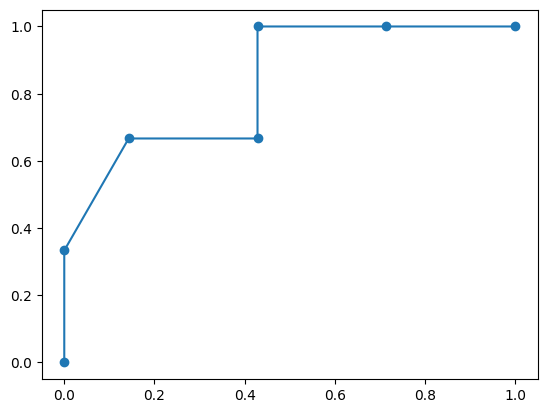

In [76]:
plt.plot(fprs, tprs, "o-")

In [18]:
def auroc(actual : List | NDArray, confidences : List | NDArray, thresholds : List | NDArray) -> Dict[str , NDArray| float]:
    assert len(actual) == len(confidences)

    # # Idea: Generate a matrix, where each row contains the confidence values
    # confidence_matrix = tf.broadcast_to(confidences, (len(thresholds), len(confidences)))
    # # Now generate a matrix where each column is the threshold values
    # threshold_matrix = tf.broadcast_to(tf.reshape(thresholds, (-1, 1)), (len(thresholds), len(confidences)))
    # # Now perform a greater than operation, elementwise
    # predictions_per_threshold = tf.greater_equal(confidence_matrix, threshold_matrix)

    predictions_per_threshold = tf.greater_equal(confidences, tf.reshape(thresholds, (-1, 1)))

    tprs = true_positive_rates(actual, predictions_per_threshold)
    fprs = false_positive_rates(actual, predictions_per_threshold)

    area = 0

    for i in range(len(tprs) - 1):
        width = fprs[i + 1] - fprs[i]
        height = (tprs[i + 1] + tprs[i]) / 2
        area += width.numpy() * height.numpy()
    return {
        "value" : -area,
        "tprs" : tprs,
        "fprs" : fprs
    }

0.8333333333333333


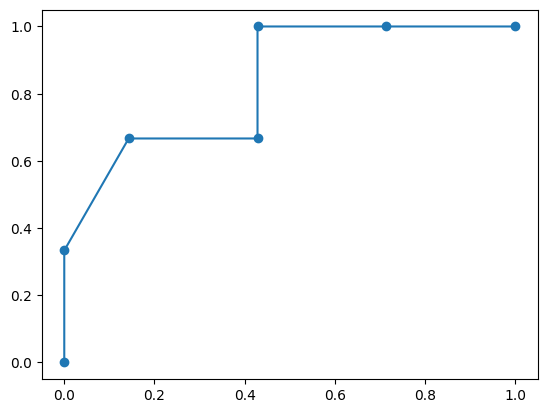

In [28]:
skilled = auroc(handpicked_data_set, handpicked_model_confidences, thresholds)

print(skilled["value"])
plt.plot(skilled["fprs"], skilled["tprs"], marker="o")

In [31]:
unskilled = auroc(data_set, model_confidences, [0.02*i for i in range(51)])
print(unskilled["value"])

0.5014300677138335


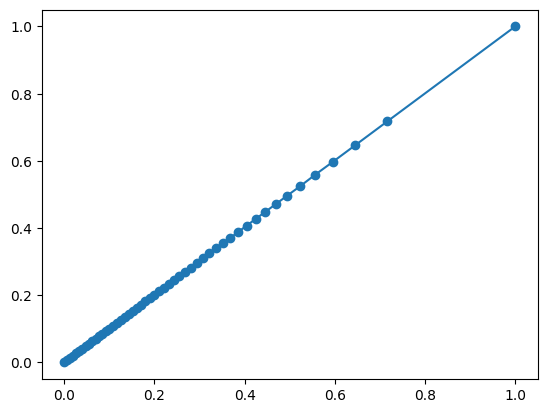

In [33]:
plt.plot(unskilled["fprs"], unskilled["tprs"], marker="o")